In [1]:
import numpy as np
from astroNN.datasets import load_galaxy10
import pandas as pd
from matplotlib import pyplot as plt 
import os
import h5py
import yaml
import torch
import torchvision.transforms.functional as TF
%load_ext autoreload
%autoreload 2


import src.train as train
import src.dataset
import src.architectures as architectures
import src.utils as utils

In [ ]:
with h5py.File(full_directory, 'r') as f:
    # Load the 17,736 images (shape: 17736 x 256 x 256 x 3)
    images = np.array(f['images'])
    
    # Load the classification labels (shape: 17736)
    labels = np.array(f['ans'])
    
    # You also have access to the following arrays:
    # ra = np.array(f['ra'])
    # dec = np.array(f['dec'])
    # redshift = np.array(f['redshift'])
    # pxscale = np.array(f['pxscale'])
print(f"Images array shape: {images.shape}")
print(f"Labels array shape: {labels.shape}")

In [5]:
images, labels = load_galaxy10()

/Users/amir/.astroNN/datasets/Galaxy10_DECals.h5 was found!


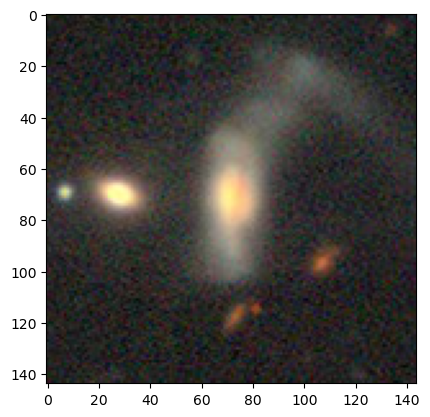

In [16]:
import matplotlib.pyplot as plt

# Assuming 'image' is a NumPy array of shape (255, 255, 3) or (256, 256, 3)
H, W = images[0].shape[:2]
crop_size = 144

# Calculate the start indices
start_y = (H - crop_size) // 2
start_x = (W - crop_size) // 2

# Slice the array!
cropped_image = images[0,start_y : start_y + crop_size, start_x : start_x + crop_size]

plt.imshow(cropped_image)
plt.show()


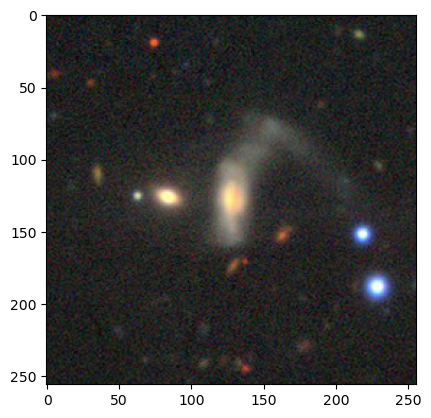

In [17]:
plt.imshow(images[0])

In [11]:
labels_unique = np.unique(labels)
values, counts = labels_unique,return_counts = True
print(sum(counts))

TypeError: cannot unpack non-iterable bool object

In [15]:
unique_vals, counts = np.unique(labels, return_counts=True)
# Print the results nicely
for val, count in zip(unique_vals, counts):
    print(f"Label {val}: {count} times")

weights = np.array(counts) / len(labels)


print (weights)


Label 0: 1081 times
Label 1: 1853 times
Label 2: 2645 times
Label 3: 2027 times
Label 4: 334 times
Label 5: 2043 times
Label 6: 1829 times
Label 7: 2628 times
Label 8: 1423 times
Label 9: 1873 times
[0.06094948 0.10447677 0.14913171 0.11428733 0.01883175 0.11518945
 0.10312359 0.14817321 0.0802323  0.10560442]


In [19]:
counts = np.bincount(labels)
weights = (len(labels) / (len(counts) * counts))**-1

print(weights)

[0.60949481 1.0447677  1.4913171  1.14287325 0.18831755 1.15189445
 1.0312359  1.48173207 0.80232296 1.0560442 ]


Loading train images into memory...
Loaded 12415 images into RAM for train split.
Loading val images into memory...
Loaded 2660 images into RAM for val split.
Loading test images into memory...
Loaded 2661 images into RAM for test split.
--- Loading SSL Backbone Weights ---
Load Status: _IncompatibleKeys(missing_keys=['fc.weight', 'fc.bias'], unexpected_keys=[])
Backbone UNFROZEN. Fully fine-tuning the entire network.
Engaging LP-FT Mode: Linear Probing for 20 epochs, then Full Fine-Tuning.
Current Learning Rate: 0.009939057285945933
--- New Best Val Acc! Model Saved ---
In epoch number 0: Train Loss: 1.5003, Train Acc: 0.4734, Val Loss: 1.1595, Val Acc: 0.5936
Current Learning Rate: 0.009757729755661013
In epoch number 1: Train Loss: 1.3495, Train Acc: 0.5133, Val Loss: 1.1977, Val Acc: 0.5737
Current Learning Rate: 0.009460482294732423
In epoch number 2: Train Loss: 1.3625, Train Acc: 0.5218, Val Loss: 1.1964, Val Acc: 0.5714
Current Learning Rate: 0.009054634122155993
--- New Best V

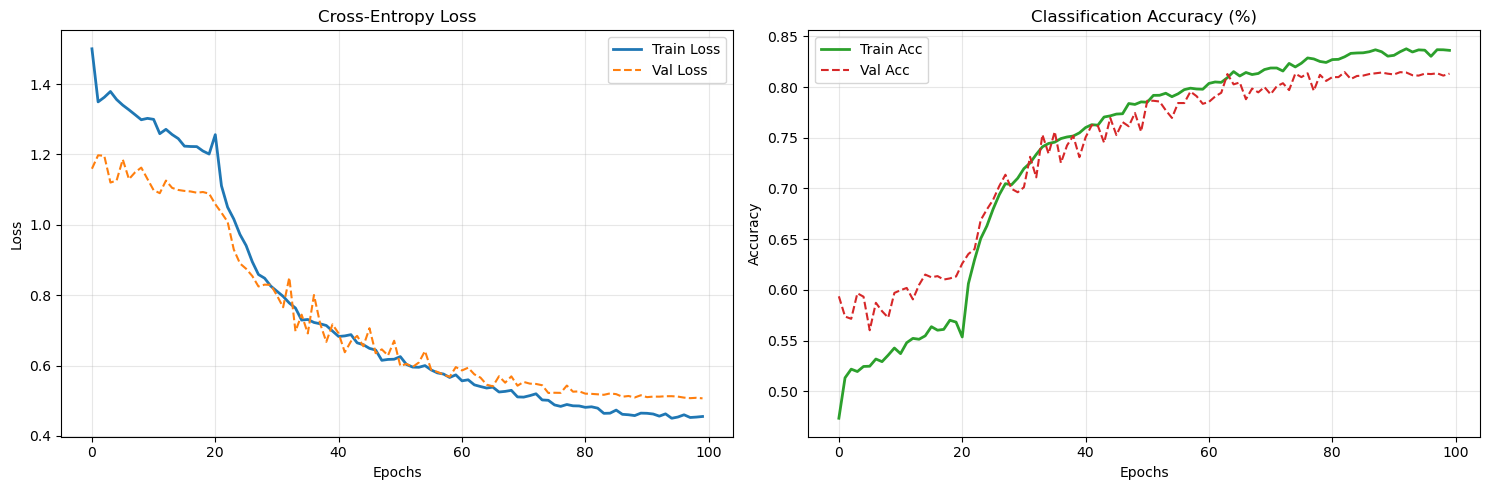

FileNotFoundError: [Errno 2] No such file or directory: 'models/best_model_linear_probe.pth'

In [2]:
train.main()

In [14]:
model = architectures.CNNclassifier()
model.to(torch.device('mps'))

model.load_state_dict(torch.load(f'models/CNN model/best_model_supervised_CNN.pth'))

# Generate final reports
y_true, y_pred = utils.get_all_predictions(model, test_dataloader, device)
utils.print_performance_report(y_true, y_pred, class_names)
cm_save_name = 'CNN baseline confusion matrix'
utils.plot_confusion_matrix(y_true, y_pred, class_names, save_path=f'models/{cm_save_name}')

NameError: name 'test_dataloader' is not defined

In [6]:
main_ssl()

PicklingError: Can't pickle <class 'src.dataset.GalaxyDataset'>: it's not the same object as src.dataset.GalaxyDataset